https://quimb.readthedocs.io/en/latest/tensor/tensor-basics.html#creating-tensors

In [9]:
import quimb as qu
import quimb.tensor as qtn
import networkx as nx

Tensor(shape=(2, 2), inds=('k0', 'k1'), tags=oset(['KET']), backend='numpy', dtype='complex128')


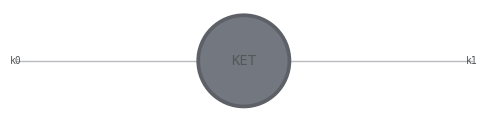

In [10]:
data = qu.bell_state("psi-").reshape(2, 2) # just a raw data array
inds = ("k0", "k1") # indices to lable the dimensions
tags = ("KET",)

ket = qtn.Tensor(data=data, inds=inds, tags=tags)
print(ket)
ket.draw()

This is a n-dimension array -> and autoray object (an array optimized by the lib autoray)

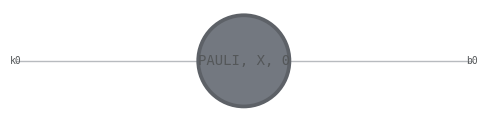

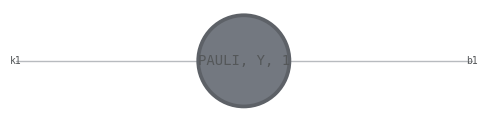

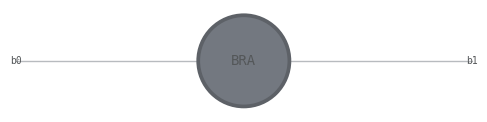

In [11]:
X = qtn.Tensor(qu.pauli("X"), inds=("k0", "b0"), tags=["PAULI", "X", "0"])
Y = qtn.Tensor(qu.pauli("Y"), inds=("k1", "b1"), tags=["PAULI", "Y", "1"])

bra = qtn.Tensor(qu.rand_ket(4).reshape(2, 2), inds=("b0", "b1"), tags=["BRA"])
X.draw()
Y.draw()
bra.draw()

rand_ket() ->
- Generate a vector of d random numbers (d = 4).
- Interpret it as a ket.
- Normalize it to norm 1.

TensorNetwork(tensors=2, indices=4)

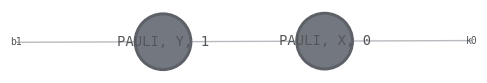

In [12]:
# Let's join 2 ket:
tn = (X | Y) # tensor network
display(tn)
qtn.connect(X,Y,1,0)
tn.draw()

before we had 
- **X**: k0--Pauli X--b0
- **Y**: k1--Pauli Y--b1

now we got something like

- **tensor network XT**: k0--Pauli X-- **[shared index(b0--k1)]** --Pauli Y--b1

Now the Tensor created above are in a tensor network connected together (stil not contracted).

# SVD application

Let's apply the SVD on a base state and build a tensor by using the $U^{(n)}s$ matrix of the iterative SVD method: 
$$ A^{(1)} = U^{(1)}S^{(1)}V^{\dagger(1)} $$

**IDEA**: Starting from the state $|000...0>$ (this occupy much less memory) and we want to create a state by using a quantum algorithm. So the SVD will be used by compressing the gate which create the entanglement such as $C_{NOT}$ in order to maitain Tensor Train structure. So We want to apply the **Time-Evolving Block Decimation**

In [13]:
# creating the initial state
n = 10 
mps = qtn.MPS_computational_state("0" * n) # state on length 10 full of zeros
print(mps)
print("Bond dimensions:", mps.bond_sizes()) 

MatrixProductState([
    Tensor(shape=(1, 2), inds=('_cac4e3AAABM', 'k0'), tags=oset(['I0'])),
    Tensor(shape=(1, 1, 2), inds=('_cac4e3AAABM', '_cac4e3AAABN', 'k1'), tags=oset(['I1'])),
    Tensor(shape=(1, 1, 2), inds=('_cac4e3AAABN', '_cac4e3AAABO', 'k2'), tags=oset(['I2'])),
    Tensor(shape=(1, 1, 2), inds=('_cac4e3AAABO', '_cac4e3AAABP', 'k3'), tags=oset(['I3'])),
    Tensor(shape=(1, 1, 2), inds=('_cac4e3AAABP', '_cac4e3AAABQ', 'k4'), tags=oset(['I4'])),
    Tensor(shape=(1, 1, 2), inds=('_cac4e3AAABQ', '_cac4e3AAABR', 'k5'), tags=oset(['I5'])),
    Tensor(shape=(1, 1, 2), inds=('_cac4e3AAABR', '_cac4e3AAABS', 'k6'), tags=oset(['I6'])),
    Tensor(shape=(1, 1, 2), inds=('_cac4e3AAABS', '_cac4e3AAABT', 'k7'), tags=oset(['I7'])),
    Tensor(shape=(1, 1, 2), inds=('_cac4e3AAABT', '_cac4e3AAABU', 'k8'), tags=oset(['I8'])),
    Tensor(shape=(1, 2), inds=('_cac4e3AAABU', 'k9'), tags=oset(['I9'])),
], tensors=10, indices=19, L=10, max_bond=1)
Bond dimensions: [1, 1, 1, 1, 1, 1, 1, 1, 

The bonds are 1s so it means that there is no correlation between the qubits of mps initial state.

In [14]:
# reinit the initial state
mps = qtn.MPS_computational_state("0" * n)

gate_opts = {
    'max_bond': 4,       # value of chi_max
    'cutoff': 1e-8,      # minimum to cut singular values
    'method': 'svd',     
}

# Hadamard only on controlled qubits 
H = qu.hadamard()
for i in range(0, n, 2):
    mps.gate_(H, where=i)
    mps.contract_tags_(f"I{i}")

print("Bond dimensions after the application of 1 qubit gates (Hadamard gate):", mps.bond_sizes())

# gate to create entanglement between qubits
CNOT = qu.CNOT()
trunc_error = []

# Layer 1: CNOT between (0,1), (2,3), (4,5)
for i in range(0, n, 2):
    information = {}
    mps.gate_split_(CNOT, where=(i, i + 1), info=information, **gate_opts)
    err = information.get('err', 0.0)
    trunc_error.append(err)
    print(f"CNOT ({i}, {i+1})-> truncate error: {err:.6e}, Bond size update: {mps.bond_size(i, i+1)}")

# Layer 2: CNOT between (1,2), (3,4) (more entanglement)
for i in range(1, n - 1, 2):
    information = {}
    mps.gate_split_(CNOT, where=(i, i + 1), info=information, **gate_opts)
    err = information.get('err', 0.0)
    trunc_error.append(err)
    print(f"CNOT ({i}, {i+1})-> truncate error: {err:.6e}, Bond size update: {mps.bond_size(i, i+1)}") 

print("New Bonds dim:", mps.bond_sizes())

# Last step is to noramlize and check the max bonds
mps.normalize()
print(f"\n Norm: {mps.norm():.4f}")
print(f"\n chi_max: {mps.max_bond()}")
print(f"\n max error on a single cut: {max(trunc_error):.6e}")
print(f"\n sum of local errors: {sum(trunc_error):.6e}")

Bond dimensions after the application of 1 qubit gates (Hadamard gate): [1, 1, 1, 1, 1, 1, 1, 1, 1]
CNOT (0, 1)-> truncate error: 0.000000e+00, Bond size update: 2
CNOT (2, 3)-> truncate error: 0.000000e+00, Bond size update: 2
CNOT (4, 5)-> truncate error: 0.000000e+00, Bond size update: 2
CNOT (6, 7)-> truncate error: 0.000000e+00, Bond size update: 2
CNOT (8, 9)-> truncate error: 0.000000e+00, Bond size update: 2
CNOT (1, 2)-> truncate error: 0.000000e+00, Bond size update: 2
CNOT (3, 4)-> truncate error: 0.000000e+00, Bond size update: 2
CNOT (5, 6)-> truncate error: 0.000000e+00, Bond size update: 2
CNOT (7, 8)-> truncate error: 0.000000e+00, Bond size update: 2
New Bonds dim: [2, 2, 2, 2, 2, 2, 2, 2, 2]

 Norm: 1.0000

 chi_max: 2

 max error on a single cut: 0.000000e+00

 sum of local errors: 0.000000e+00


the error is zero because of the max chi is ssetted to 4 and we naturally reach a maxbond of 2 with this algorithm so there is no cut. 

In [15]:
mps.show()

 2 2 2 2 2 2 2 2 2 
●─●─●─●─●─●─●─●─●─●
│ │ │ │ │ │ │ │ │ │


## GHZ State

In [73]:
n_qubit = 10
initial_state = qtn.MPS_computational_state(n_qubit * "0")
initial_state.show()

 1 1 1 1 1 1 1 1 1 
>─>─>─>─>─>─>─>─>─●
│ │ │ │ │ │ │ │ │ │


In [74]:
H = qu.hadamard()
hadamard_app = initial_state.gate(H, where=0, contract=True)
hadamard_app.show()

 1 1 1 1 1 1 1 1 1 
>─>─>─>─>─>─>─>─>─●
│ │ │ │ │ │ │ │ │ │


In [75]:
gate_opts = {
    'max_bond': 4,       # value of chi_max
    'cutoff': 1e-8,      # minimum to cut singular values
    'method': 'svd',     
}

CNOT = qu.CNOT()

ghz = hadamard_app

trunc_error=[]
for i in range (n_qubit - 2):
    info1 = {}
    info2 = {}
    ghz.gate_split(CNOT, where=(i, i+1), info=info1, inplace=True, **gate_opts)
    # non-local so not applicable with gate_split (this apply in automatic the SWAPS gates to apply the CNOT)
    ghz.gate_with_auto_swap(CNOT, where=(i, i+2), info=info2, inplace=True, swap_back=True, **gate_opts) 
    err1 = info1.get('err', info1.get('error', 0.0))
    err2 = info2.get('err', info2.get('error', 0.0))
    trunc_error.extend([err1, err2])
    print(f"CNOT ({i}, {i+1})-> truncate error1: {err1:.6e}; truncate error2: {err2:.6}, Bond size update: {ghz.bond_size(i, i+1)}")

ghz.normalize()
print(f"error by truncation = {sum(trunc_error)}")

ghz.show()

CNOT (0, 1)-> truncate error1: 0.000000e+00; truncate error2: 0.0, Bond size update: 2
CNOT (1, 2)-> truncate error1: 0.000000e+00; truncate error2: 0.0, Bond size update: 2
CNOT (2, 3)-> truncate error1: 0.000000e+00; truncate error2: 0.0, Bond size update: 2
CNOT (3, 4)-> truncate error1: 0.000000e+00; truncate error2: 0.0, Bond size update: 2
CNOT (4, 5)-> truncate error1: 0.000000e+00; truncate error2: 0.0, Bond size update: 2
CNOT (5, 6)-> truncate error1: 0.000000e+00; truncate error2: 0.0, Bond size update: 2
CNOT (6, 7)-> truncate error1: 0.000000e+00; truncate error2: 0.0, Bond size update: 2
CNOT (7, 8)-> truncate error1: 0.000000e+00; truncate error2: 0.0, Bond size update: 2
error by truncation = 0.0
 2 2 2 2 2 2 2 2 2 
>─>─>─>─>─>─>─>─>─●
│ │ │ │ │ │ │ │ │ │


**GATE WITH AUTO SWAP (quimb from documentation)**

Perform a two site gate on this MPS by, if necessary, swapping and compressing the sites until they are adjacent, using gate_split, then unswapping the sites back to their original position.

PARAMETERS:
- **G (array)** – The gate, with shape (d**2, d**2) for physical dimension d.
- **where ((int, int))** – Indices of the sites to apply the gate to.
- **info (dict, optional)** – If supplied, will be used to infer and store various extra information. Currently, the key “cur_orthog” is used to store the current orthogonality center. Its input value can be "calc", a single site, or a pair of sites representing the min/max range, inclusive. It will be updated to the actual range after.
- **swap_back (bool, optional)** – Whether to swap the sites back to their original position after applying the gate. If not, for sites i < j, the site j will remain swapped to i + 1, and sites between i + 1 and j will be shifted one place up.
- **inplace (bond, optional)** – Perform the swaps inplace.
- **compress_opts** – Supplied to tensor_split().

### The next circuit is from Claude to check the errors from truncation

In [1]:
import quimb as qu, quimb.tensor as qtn
import numpy as np
np.random.seed(0)

n = 12

# Build the state EXACTLY (max_bond=None -> no truncation at all) with a
# random brickwork circuit, so its bond dimension grows to whatever the
# entanglement actually demands.
mps_exact = qtn.MPS_computational_state("0" * n)
depth = 6
for d in range(depth):
    offset = d % 2
    for i in range(offset, n - 1, 2):
        U = qu.rand_uni(4).reshape(2, 2, 2, 2)
        mps_exact.gate_(U, where=(i, i + 1), contract='split',
                         max_bond=None, cutoff=0.0)
mps_exact.normalize()

print("Exact (untruncated) bond dimensions:", mps_exact.bond_sizes())
print("Exact chi_max:", mps_exact.max_bond(), " <-  this is >> 4")

# Now compress a COPY down to chi_max = 4 and measure the real error.
mps_trunc = mps_exact.copy()
mps_trunc.compress(max_bond=4, cutoff=0.0)
mps_trunc.normalize()

print("\nTruncated bond dimensions:", mps_trunc.bond_sizes())
print("Truncated chi_max:", mps_trunc.max_bond())

overlap = mps_exact.H @ mps_trunc
infidelity = 1 - abs(overlap) ** 2
state_dist = (mps_exact - mps_trunc).norm()

print(f"\noverlap  <psi_exact|psi_trunc>      = {overlap:.6f}")
print(f"truncation error  1 - |overlap|^2   = {infidelity:.6e}")
print(f"||psi_exact - psi_trunc|| (2-norm)  = {state_dist:.6e}")

print("\nPlotting the TT MPS truncated:")
mps_trunc.show()
print("\nPlotting the TT exact MPS:")
mps_exact.show()


Exact (untruncated) bond dimensions: [2, 4, 8, 16, 32, 64, 32, 16, 8, 4, 2]
Exact chi_max: 64  <-  this is >> 4

Truncated bond dimensions: [2, 4, 4, 4, 4, 4, 4, 4, 4, 4, 2]
Truncated chi_max: 4

overlap  <psi_exact|psi_trunc>      = 0.881800+0.000000j
truncation error  1 - |overlap|^2   = 2.224295e-01
||psi_exact - psi_trunc|| (2-norm)  = 4.862107e-01

Plotting the TT MPS truncated:
 2 4 4 4 4 4 4 4 4 4 2 
●─●─●─●─●─●─●─●─●─●─●─●
│ │ │ │ │ │ │ │ │ │ │ │

Plotting the TT exact MPS:
 2 4 8 16 32 64 32 16 8 4 2 
●─●─●─●──●──●──●──●──●─●─●─●
│ │ │ │  │  │  │  │  │ │ │ │


/Users/feliceferrara/git/OTP-project-TuD/.venv/lib/python3.9/site-packages/autoray/autoray.py:94: RuntimeWarning: divide by zero encountered in matmul
  return func(*args, **kwargs)
/Users/feliceferrara/git/OTP-project-TuD/.venv/lib/python3.9/site-packages/autoray/autoray.py:94: RuntimeWarning: overflow encountered in matmul
  return func(*args, **kwargs)
/Users/feliceferrara/git/OTP-project-TuD/.venv/lib/python3.9/site-packages/autoray/autoray.py:94: RuntimeWarning: invalid value encountered in matmul
  return func(*args, **kwargs)
/Users/feliceferrara/git/OTP-project-TuD/.venv/lib/python3.9/site-packages/cotengra/hyperoptimizers/hyper.py:55: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization. It is recommended to install one of these libraries for higher quality contraction paths.
  warnings.warn(


## Testing mps_utils.py


In [20]:
import importlib
import mps_utils

importlib.reload(mps_utils)
mps = mps_utils.create_ghz_state(n_qubits=10)
mps.show()

state = mps_utils.create_high_entangled_state(n_qubits=15, max_bond=None, seed=42)
trunc_state, report = mps_utils.evaluate_truncation_error(mps_exact=state,
                                                           max_bond=3)

print(f"Infidelity: {report['infidelity']:.4e}")
print(f"\nError: {report['norm_distance']}")
print(f"\nOverlap: {report['overlap']}")
trunc_state.show()
state.show()

 2 2 2 2 2 2 2 2 2 
●─●─●─●─●─●─●─●─●─●
│ │ │ │ │ │ │ │ │ │
Infidelity: 7.0597e-01

Error: 0.9568183522417077

Overlap: (0.5422493204067323+2.594495798757812e-16j)
 2 3 3 3 3 3 3 3 3 3 3 3 3 2 
●─●─●─●─●─●─●─●─●─●─●─●─●─●─●
│ │ │ │ │ │ │ │ │ │ │ │ │ │ │
 2 4 8 16 32 64 32 64 32 32 16 8 4 2 
●─●─●─●──●──●──●──●──●──●──●──●─●─●─●
│ │ │ │  │  │  │  │  │  │  │  │ │ │ │


/Users/feliceferrara/git/OTP-project-TuD/.venv/lib/python3.9/site-packages/autoray/autoray.py:94: RuntimeWarning: divide by zero encountered in matmul
  return func(*args, **kwargs)
/Users/feliceferrara/git/OTP-project-TuD/.venv/lib/python3.9/site-packages/autoray/autoray.py:94: RuntimeWarning: overflow encountered in matmul
  return func(*args, **kwargs)
/Users/feliceferrara/git/OTP-project-TuD/.venv/lib/python3.9/site-packages/autoray/autoray.py:94: RuntimeWarning: invalid value encountered in matmul
  return func(*args, **kwargs)
